# Otimização de Função com PSO

Imagine que temos um terreno montanhoso (a função matemática X^2) e soltamos 30 "drones" (partículas) no escuro. Eles não veem o mapa, mas sabem a altitude atual e comunicam-se entre si.

        Objetivo: Encontrar o ponto mais baixo do vale (Mínimo Global).

        Mecânica: Cada drone ajusta sua velocidade baseado em:

            Memória Pessoal (Pbest​): O lugar mais baixo que ele já visitou.

            Influência Social (Gbest​): O lugar mais baixo que qualquer um do grupo já visitou.

A linha mais importante do código é a atualização da velocidade. Em notação matemática, ela é definida como:

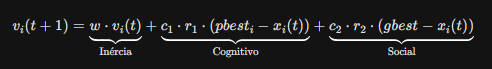

        Inércia (w): Evita mudanças bruscas. Se o drone estava indo rápido para o Norte, ele tende a continuar indo.

        Cognitivo (c1​): Puxa o drone de volta para o melhor lugar que ele já viu.

        Social (c2​): Puxa o drone em direção ao melhor lugar que o líder do bando encontrou.

In [9]:
import numpy as np
import random

In [10]:
# ███████╗██╗   ██╗███╗   ██╗ ██████╗ ██████╗ ███████╗███████╗
# ██╔════╝██║   ██║████╗  ██║██╔════╝██╔═══██╗██╔════╝██╔════╝
# █████╗  ██║   ██║██╔██╗ ██║██║     ██║   ██║█████╗  ███████╗
# ██╔══╝  ██║   ██║██║╚██╗██║██║     ██║   ██║██╔══╝  ╚════██║
# ██║     ╚██████╔╝██║ ╚████║╚██████╗╚██████╔╝███████╗███████║
# ╚═╝      ╚═════╝ ╚═╝  ╚═══╝ ╚═════╝ ╚═════╝ ╚══════╝╚══════╝

class ParticleSwarmOptimizer:
    def __init__(self, func, n_particles, dimensions, bounds, max_iter, w=0.7, c1=1.5, c2=1.5):
        """
        Inicializa o Otimizador PSO.
        
        argumentos:
            func: A função de custo a ser minimizada.
            n_particles: Número de partículas (drones).
            dimensions: Número de variáveis (ex: 2 para X e Y).
            bounds: Tupla (min, max) definindo os limites do espaço de busca.
            max_iter: Número máximo de iterações.
            w: Peso de inércia (mantém o movimento atual).
            c1: Coeficiente cognitivo (atração pelo próprio melhor histórico).
            c2: Coeficiente social (atração pelo melhor histórico do grupo).
        """
        self.func = func
        self.n_particles = n_particles
        self.dim = dimensions
        self.bounds = bounds
        self.max_iter = max_iter
        self.w = w
        self.c1 = c1
        self.c2 = c2
        
        # Inicialização das Partículas (Posição e Velocidade Aleatórias)
        self.X = np.random.uniform(bounds[0], bounds[1], (n_particles, dimensions))
        self.V = np.random.uniform(-1, 1, (n_particles, dimensions))
        
        # Melhor posição pessoal de cada partícula (Pbest)
        self.Pbest_X = self.X.copy()
        self.Pbest_obj = np.array([func(x) for x in self.X])
        
        # Melhor posição global (Gbest)
        self.Gbest_index = np.argmin(self.Pbest_obj)
        self.Gbest_X = self.Pbest_X[self.Gbest_index].copy()
        self.Gbest_obj = self.Pbest_obj[self.Gbest_index]

    def optimize(self):
        history = [] # Para armazenar o progresso
        
        print(f"Iniciando Otimização com {self.n_particles} partículas...")
        
        for i in range(self.max_iter):
            # Atualizar Velocidades
            # r1, r2 são vetores aleatórios entre 0 e 1 (estocasticidade)
            r1 = np.random.rand(self.n_particles, self.dim)
            r2 = np.random.rand(self.n_particles, self.dim)
            
            # Equação Fundamental do PSO
            # V_novo = Inércia + Componente Cognitivo + Componente Social
            self.V = (self.w * self.V) + \
                     (self.c1 * r1 * (self.Pbest_X - self.X)) + \
                     (self.c2 * r2 * (self.Gbest_X - self.X))
            
            # Atualizar Posições
            self.X = self.X + self.V
            
            # Aplicar limites (Clamping) para não sair do mapa
            self.X = np.clip(self.X, self.bounds[0], self.bounds[1])
            
            # Avaliar Função de Custo (Fitness)
            current_obj = np.array([self.func(x) for x in self.X])
            
            # Atualizar Pbest (Melhor Pessoal)
            # Verifica onde a nova posição é melhor que a histórica
            improved_indices = current_obj < self.Pbest_obj
            self.Pbest_X[improved_indices] = self.X[improved_indices]
            self.Pbest_obj[improved_indices] = current_obj[improved_indices]
            
            # Atualizar Gbest (Melhor Global)
            current_best_index = np.argmin(self.Pbest_obj)
            if self.Pbest_obj[current_best_index] < self.Gbest_obj:
                self.Gbest_obj = self.Pbest_obj[current_best_index]
                self.Gbest_X = self.Pbest_X[current_best_index].copy()
            
            history.append(self.Gbest_obj)
            
            # Log opcional a cada 10 iterações
            if i % 10 == 0:
                print(f"Iter {i}: Melhor Custo Global = {self.Gbest_obj:.6f}")
                
        return self.Gbest_X, self.Gbest_obj, history

In [11]:
# ███████╗██╗  ██╗███████╗ ██████╗██╗   ██╗ ██████╗ █████╗  ██████╗
# ██╔════╝╚██╗██╔╝██╔════╝██╔════╝██║   ██║██╔════╝██╔══██╗██╔═══██╗
# █████╗   ╚███╔╝ █████╗  ██║     ██║   ██║██║     ███████║██║   ██║
# ██╔══╝   ██╔██╗ ██╔══╝  ██║     ██║   ██║██║     ██╔══██║██║   ██║
# ███████╗██╔╝ ██╗███████╗╚██████╗╚██████╔╝╚██████╗██║  ██║╚██████╔╝
# ╚══════╝╚═╝  ╚═╝╚══════╝ ╚═════╝ ╚═════╝  ╚═════╝╚═╝  ╚═╝ ╚═════╝

# Definindo uma função objetivo clássica: "Sphere Function"
# O mínimo é 0 em (0,0,0...)
def sphere_function(x):
    return np.sum(x**2)

# Configuração
pso = ParticleSwarmOptimizer(
    func=sphere_function,
    n_particles=30,
    dimensions=3,    # Espaço 3D (X, Y, Z)
    bounds=(-10, 10),# Busca entre -10 e 10
    max_iter=50
)

# Execução
best_solution, best_value, history = pso.optimize()

print("\n--- Resultado Final ---")
print(f"Melhor Posição Encontrada: {best_solution}")
print(f"Valor da Função (Custo): {best_value:.10f}")
print("(Deveria ser muito próximo de 0)")

Iniciando Otimização com 30 partículas...
Iter 0: Melhor Custo Global = 3.477430
Iter 10: Melhor Custo Global = 0.053943
Iter 20: Melhor Custo Global = 0.014776
Iter 30: Melhor Custo Global = 0.000099
Iter 40: Melhor Custo Global = 0.000030

--- Resultado Final ---
Melhor Posição Encontrada: [-0.00065499  0.00114077 -0.00083036]
Valor da Função (Custo): 0.0000024199
(Deveria ser muito próximo de 0)
